# Adversarial Threats to Cloud IDS — PyTorch Reimplementation (Local / RX7600 DirectML)

Reimplements the methodology from *"Adversarial Threats to Cloud IDS: Robust Defense With
Adversarial Training and Feature Selection"* (Holla, Polepalli & Sasikumar, IEEE Access 2025)
on the `solarmainframe/ids-intrusion-csv` (CSE-CIC-IDS2018) dataset, using **PyTorch** instead
of TensorFlow.

**This variant:** reads CSVs from a local `data/` folder and trains on your AMD RX7600 8GB GPU via **torch-directml**.

**GPU/CPU split (important):**
- Model **training and plain inference** run on DirectML (your RX7600) — this is where most wall-clock time goes, so it's accelerated.
- **ART (Adversarial Robustness Toolbox) attack generation — FGSM, PGD, DeepFool — always runs on CPU.**
  DirectML does not reliably support the autograd + numpy interop ART needs for gradient-based attacks, so each attack step copies the model's weights to a plain CPU model and attacks that copy instead.
- The custom **tabular Square Attack** (black-box, gradient-free) and **SHAP** analysis are pure forward passes, so those *do* use the GPU for speed.

**Fixes carried over / added vs. the original TF-based v2 notebook:**
- Table 4 (accuracy under attack) now reports **all four** paper metrics — Accuracy, F1, Precision, Recall — not just Accuracy/F1.
- Every cell prints a timestamped status line or progress bar; nothing runs silently.
- Dataset quirks handled: duplicate columns, embedded header rows, `'Infinity'`/blank strings in rate columns.
- ART's built-in `SquareAttack` only supports image tensors — replaced with a tabular-adapted random-search reimplementation (unchanged from v2).
- Attack epsilon defaults to a value that degrades the baseline gradually (paper never states its exact epsilon/iteration counts — see `CONFIG`).

**Folders:** dataset must be placed in `./data/` (any of the 10 daily CSE-CIC-IDS2018 CSVs). All outputs (tables, plots, models, metrics) are saved under ``./output``.


## Section 1 — Install packages

In [1]:
# Local machine (Windows, AMD RX7600 8GB): torch-directml gives GPU acceleration
# without needing an NVIDIA/CUDA or AMD/ROCm stack. DirectML is a Windows-only technology
# (works natively on Windows, and inside WSL2 on Windows too).
!pip install -q torch-directml
!pip install -q adversarial-robustness-toolbox shap imbalanced-learn tqdm pandas scikit-learn matplotlib



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section 2 — Imports, structured logger, and config
onehot function
Every cell below prints timestamped progress lines / progress bars — there is no cell that runs silently with a blank wait.

In [2]:
import os, glob, time, json, pickle, shutil, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import shap
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, DeepFool
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


class Logger:
    """Structured logger: every step prints a timestamped, labeled line. No silent/blank cells."""
    def __init__(self):
        self.t0 = time.time()
        self.section_num = 0

    def _elapsed(self):
        s = time.time() - self.t0
        m, s = divmod(s, 60)
        h, m = divmod(m, 60)
        return f"{int(h):02d}:{int(m):02d}:{s:05.2f}"

    def section(self, title):
        self.section_num += 1
        bar = "=" * 78
        print(f"\n{bar}")
        print(f">>> [{self._elapsed()}] SECTION {self.section_num}: {title}")
        print(bar)

    def info(self, msg):
        print(f"    . [{self._elapsed()}] {msg}")

    def ok(self, msg):
        print(f"    v [{self._elapsed()}] {msg}")

    def warn(self, msg):
        print(f"    ! [{self._elapsed()}] WARNING: {msg}")

    def metric(self, label, value):
        print(f"    > [{self._elapsed()}] {label:<42s} {value}")


log = Logger()
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIG = {
        "day_patterns": None,           # None = load all files found in data/ (now targeting all 10 days)
    "max_rows_per_file": None,      # set e.g. 500_000 if you hit RAM/SMOTE slowness with the full 10-day set
    "top_t_mutual_info": 25,       # features kept after MI ranking (paper Table 2, T unspecified)
    "top_t_shap": 15,              # features kept after SHAP stability ranking (paper Table 3, T unspecified)
    "attack_eps": 0.05,            # L_inf budget on standardized features; 0.15 was empirically too strong
    "pgd_iters": 20,
    "deepfool_iters": 50,
    "square_iters": 300,
    "n_attack_eval_samples": 2000, # test-set subsample used to evaluate attacks
    "n_square_samples": 1000,
    "n_shap_samples": 300,
    "n_adv_train_samples": 5000,   # clean samples used per attack type to build adversarial training data
    "epochs_baseline": 50,
    "epochs_defended_stage1": 50,  # FIX: match baseline epoch count exactly (was 25) so overhead
                                    # isolates the cost Stage 2 + attack-gen add, not a shorter run
    "epochs_defended_stage2": 15,  # this is the real "added" cost
    "batch_size": 512,
}
log.info(f"CONFIG = {json.dumps(CONFIG, indent=2)}")
log.info(f"Outputs will be saved to: {OUTPUT_DIR}")


def to_onehot(y, n_classes=2):
    """ART's PyTorchClassifier expects one-hot y for generate() ground-truth targeting."""
    return np.eye(n_classes, dtype=np.float32)[y]

Run started: 2026-07-30 12:27:55
    . [00:00:00.00] CONFIG = {
  "day_patterns": null,
  "max_rows_per_file": null,
  "top_t_mutual_info": 25,
  "top_t_shap": 15,
  "attack_eps": 0.05,
  "pgd_iters": 20,
  "deepfool_iters": 50,
  "square_iters": 300,
  "n_attack_eval_samples": 2000,
  "n_square_samples": 1000,
  "n_shap_samples": 300,
  "n_adv_train_samples": 5000,
  "epochs_baseline": 50,
  "epochs_defended_stage1": 50,
  "epochs_defended_stage2": 15,
  "batch_size": 512
}
    . [00:00:00.00] Outputs will be saved to: ./output


## Section 3 — Device setup

In [3]:
log.section("Device setup (DirectML)")

CPU_DEVICE = torch.device("cpu")

try:
    import torch_directml
    DEVICE = torch_directml.device()
    log.ok(f"DirectML device acquired: {DEVICE}")
    try:
        log.info(f"DirectML device name: {torch_directml.device_name(0)}")
    except Exception:
        pass
except ImportError:
    log.warn("torch-directml not importable. Falling back to CPU. "
             "Install with: pip install torch-directml  (Windows only; native or WSL2).")
    DEVICE = CPU_DEVICE

log.info(f"Torch version: {torch.__version__}")
log.info(f"Training/inference device : {DEVICE}")
log.info(f"ART attack device (fixed) : {CPU_DEVICE}  (attacks always run on CPU, see intro cell)")
log.info("Tip: the model here is tiny (128-64-32 MLP). If DirectML feels no faster than CPU, "
         "try raising CONFIG['batch_size'] (e.g. 1024-4096) to amortize per-call GPU dispatch overhead.")



>>> [00:00:00.06] SECTION 1: Device setup (DirectML)
    v [00:00:00.13] DirectML device acquired: privateuseone:0
    . [00:00:00.24] DirectML device name: AMD Radeon RX 7600 
    . [00:00:00.24] Torch version: 2.4.1+cpu
    . [00:00:00.24] Training/inference device : privateuseone:0
    . [00:00:00.24] ART attack device (fixed) : cpu  (attacks always run on CPU, see intro cell)
    . [00:00:00.24] Tip: the model here is tiny (128-64-32 MLP). If DirectML feels no faster than CPU, try raising CONFIG['batch_size'] (e.g. 1024-4096) to amortize per-call GPU dispatch overhead.


## Section 4 — Load the dataset

In [4]:
log.section("Loading dataset from local data/ folder")

DATA_DIR = "data"
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"'{DATA_DIR}/' not found next to this notebook. "
        "Download the CSE-CIC-IDS2018 parquet files (Kaggle dataset "
        "'dhoogla/csecicids2018') and place them in a 'data' folder "
        "next to this notebook, then re-run this cell."
    )

all_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.parquet"), recursive=True))
if not all_files:
    # fallback in case someone drops raw CSVs in the same folder
    all_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
if not all_files:
    raise FileNotFoundError(f"No .parquet or .csv files found under '{DATA_DIR}/'. Place the dataset files there.")

log.ok(f"Found {len(all_files)} data file(s) in '{DATA_DIR}/':")
for p in all_files:
    size_mb = os.path.getsize(p) / (1024 * 1024)
    print(f"        - {os.path.basename(p)}  ({size_mb:,.1f} MB)")


>>> [00:00:00.26] SECTION 2: Loading dataset from local data/ folder
    v [00:00:00.26] Found 10 data file(s) in 'data/':
        - Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet  (79.6 MB)
        - Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet  (72.9 MB)
        - DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet  (85.3 MB)
        - DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet  (31.9 MB)
        - DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet  (94.0 MB)
        - DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet  (55.3 MB)
        - Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet  (48.6 MB)
        - Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet  (27.9 MB)
        - Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet  (99.1 MB)
        - Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet  (96.7 MB)


## Section 5 — Load selected daily files

In [5]:
log.section("Loading selected daily files")
DAY_PATTERNS = CONFIG["day_patterns"]

if DAY_PATTERNS is None:
    selected_files = all_files
else:
    selected_files = [p for p in all_files if any(pat in os.path.basename(p) for pat in DAY_PATTERNS)]
    for pat in DAY_PATTERNS:
        if not any(pat in os.path.basename(p) for p in all_files):
            log.warn(f"No file matching '{pat}' - check filenames above and adjust CONFIG['day_patterns'].")

if not selected_files:
    log.warn("No file matched day_patterns - falling back to ALL found files.")
    selected_files = all_files

MAX_ROWS_PER_FILE = CONFIG.get("max_rows_per_file")  # None = no cap, load everything

dfs = []
for p in tqdm(selected_files, desc="Loading data files"):
    if p.endswith(".parquet"):
        d = pd.read_parquet(p, engine="pyarrow")
    else:
        d = pd.read_csv(p, low_memory=False)

    # Downcast to float32 immediately - halves RAM footprint vs. float64,
    # which matters once you're loading all 10 days instead of 3.
    float_cols = d.select_dtypes(include=["float64"]).columns
    d[float_cols] = d[float_cols].astype(np.float32)

    if MAX_ROWS_PER_FILE is not None and len(d) > MAX_ROWS_PER_FILE:
        d = d.sample(n=MAX_ROWS_PER_FILE, random_state=SEED)
        log.info(f"{os.path.basename(p)}: subsampled to {MAX_ROWS_PER_FILE:,} rows")

    log.info(f"{os.path.basename(p)}: {d.shape[0]:,} rows x {d.shape[1]} cols")
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
del dfs
log.ok(f"Combined raw shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()


>>> [00:00:00.31] SECTION 3: Loading selected daily files


Loading data files:   0%|          | 0/10 [00:00<?, ?it/s]

    . [00:00:00.52] Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet: 771,587 rows x 78 cols
    . [00:00:00.64] Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet: 619,346 rows x 78 cols
    . [00:00:00.79] DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet: 954,846 rows x 78 cols
    . [00:00:00.86] DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet: 561,396 rows x 78 cols
    . [00:00:00.97] DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet: 794,812 rows x 78 cols
    . [00:00:01.05] DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet: 591,873 rows x 78 cols
    . [00:00:01.12] Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet: 456,873 rows x 78 cols
    . [00:00:01.16] Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet: 249,170 rows x 78 cols
    . [00:00:01.29] Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet: 830,224 rows x 78 cols
    . [00:00:01.41] Web2-Friday-23-02-2018_TrafficForML_CICFl

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


## Section 6 — Data cleaning

Handles four real quirks of this dataset that will otherwise throw errors or silently corrupt features:
- **Column name whitespace** (`' Label'`, `'Dst Port '`, etc.)
- **Duplicate column names** across concatenated files
- **Repeated header rows embedded mid-file** — literal rows containing the string `"Label"` as data
- **`'Infinity'` / `'-Infinity'` / blank string values** in rate columns (`Flow Byts/s`, `Flow Pkts/s`) when flow duration is zero

In [6]:
log.section("Data cleaning")

df.columns = df.columns.str.strip()
log.info("Stripped whitespace from column names")

n_cols_before = df.shape[1]
df = df.loc[:, ~df.columns.duplicated()]
if df.shape[1] != n_cols_before:
    log.warn(f"Dropped {n_cols_before - df.shape[1]} duplicate-named column(s)")

# FIX: dhoogla's parquet build may store some columns (notably Label) as
# pandas 'category' dtype rather than 'object'. Cast category -> object
# up front so every downstream dtype check (label lookup, to_numeric loop
# in Section 7) behaves identically regardless of source format (raw CSV
# vs. cleaned parquet).
cat_cols = df.select_dtypes(include="category").columns
if len(cat_cols) > 0:
    df[cat_cols] = df[cat_cols].astype(object)
    log.info(f"Cast {len(cat_cols)} category column(s) to object: {list(cat_cols)}")

label_col = next((c for c in df.columns if c.strip().lower() == "label"), None)
if label_col is None:
    raise KeyError(f"No 'Label' column found. Available columns: {list(df.columns)}")
df = df.rename(columns={label_col: "Label"})
log.ok(f"Label column identified: '{label_col}' -> renamed to 'Label'")

before = len(df)
df = df[df["Label"].astype(str).str.strip().str.lower() != "label"]
dropped = before - len(df)
if dropped:
    log.warn(f"Dropped {dropped:,} embedded-header rows (repeated 'Label' as data)")

drop_cols = [c for c in ["Timestamp", "Flow ID", "Src IP", "Dst IP", "Source IP",
                          "Destination IP", "Src IP Addr", "Dst IP Addr"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)
    log.info(f"Dropped identity/temporal columns: {drop_cols}")

before = len(df)
df = df.drop_duplicates()
dropped = before - len(df)
log.ok(f"Dropped {dropped:,} duplicate rows (data cleaning) - {len(df):,} rows remain")


>>> [00:00:02.12] SECTION 4: Data cleaning
    . [00:00:02.12] Stripped whitespace from column names
    v [00:00:03.90] Label column identified: 'Label' -> renamed to 'Label'
    v [00:00:46.68] Dropped 573,667 duplicate rows (data cleaning) - 6,085,865 rows remain


## Section 7 — Binary labeling and categorical encoding

In [7]:
log.section("Binary labeling and encoding")

label_col = next((c for c in df.columns if c.strip().lower() == "label"), "Label")
df["y"] = (df[label_col].astype(str).str.strip().str.lower() != "benign").astype(int)
df = df.drop(columns=[label_col])
log.ok(f"Binary label created: {np.bincount(df['y'])} (0=benign, 1=attack)")

proto_col = next((c for c in df.columns if c.strip().lower() == "protocol"), None)
if proto_col is not None:
    df = pd.get_dummies(df, columns=[proto_col], prefix="proto")
    log.info(f"One-hot encoded '{proto_col}'")

# FIX: check both object AND category dtype (parquet source may use either)
non_numeric_cols = df.select_dtypes(include=["object", "category"]).columns
for c in non_numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
if len(non_numeric_cols) > 0:
    log.info(f"Coerced {len(non_numeric_cols)} non-numeric column(s) to numeric: {list(non_numeric_cols)}")
df = df.dropna()

X = df.drop(columns=["y"]).reset_index(drop=True).astype(np.float32)
y = df["y"].values.astype(np.int64)
log.ok(f"Final feature matrix: {X.shape} | class balance: {np.bincount(y)}")


>>> [00:00:47.15] SECTION 5: Binary labeling and encoding
    v [00:00:49.28] Binary label created: [4760022 1325843] (0=benign, 1=attack)
    . [00:00:50.26] One-hot encoded 'Protocol'
    v [00:00:52.12] Final feature matrix: (6085865, 79) | class balance: [4760022 1325843]


## Section 8 — Robust feature selection: mutual information + variance threshold (paper Table 2)

In [8]:
log.section("Mutual-information feature selection")

def robust_feature_selection(X, y, top_t, var_thresh=1e-5, mi_sample_size=50000, seed=SEED):
    vt = VarianceThreshold(threshold=var_thresh)
    vt.fit(X)
    kept_var = X.columns[vt.get_support()]
    log.info(f"Variance threshold kept {len(kept_var)}/{X.shape[1]} features")
    X_v = X[kept_var]

    rng = np.random.RandomState(seed)
    if len(X_v) > mi_sample_size:
        idx = rng.choice(len(X_v), mi_sample_size, replace=False)
        X_mi, y_mi = X_v.iloc[idx], y[idx]
        log.info(f"Computing mutual information on a {mi_sample_size:,}-row subsample for speed")
    else:
        X_mi, y_mi = X_v, y

    mi = mutual_info_classif(X_mi, y_mi, random_state=seed)
    mi_series = pd.Series(mi, index=X_v.columns).sort_values(ascending=False)
    selected = mi_series.head(top_t).index.tolist()
    return selected, mi_series

selected_features, mi_scores = robust_feature_selection(X, y, top_t=CONFIG["top_t_mutual_info"])
log.ok(f"Selected {len(selected_features)} features by mutual information")
print(selected_features)



>>> [00:00:52.24] SECTION 6: Mutual-information feature selection
    . [00:00:58.45] Variance threshold kept 71/79 features
    . [00:00:59.19] Computing mutual information on a 50,000-row subsample for speed
    v [00:01:12.23] Selected 25 features by mutual information
['Bwd Packets Length Total', 'Avg Bwd Segment Size', 'Subflow Bwd Bytes', 'Bwd Packet Length Mean', 'Fwd Packets Length Total', 'Subflow Fwd Bytes', 'Bwd Packet Length Max', 'Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd Packet Length Std', 'Packet Length Variance', 'Packet Length Std', 'Packet Length Mean', 'Packet Length Max', 'Avg Packet Size', 'Fwd Header Length', 'Init Fwd Win Bytes', 'Fwd IAT Max', 'Fwd IAT Total', 'Init Bwd Win Bytes', 'Flow IAT Max', 'Bwd Header Length', 'Fwd IAT Mean']


## Section 9 — Train/test split, scaling, SMOTE balancing

In [9]:
log.section("Split / scale / balance")

X_sel = X[selected_features].values
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=SEED, stratify=y
)
log.info(f"Train: {X_train.shape}  Test: {X_test.shape}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
log.ok("Standardized features (fit on train only)")

sm = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
X_train_bal = X_train_bal.astype(np.float32)
log.ok(f"SMOTE-balanced train set: {X_train_bal.shape} | class balance: {np.bincount(y_train_bal)}")



>>> [00:01:12.29] SECTION 7: Split / scale / balance
    . [00:01:16.94] Train: (4868692, 25)  Test: (1217173, 25)
    v [00:01:18.88] Standardized features (fit on train only)
    v [00:16:29.55] SMOTE-balanced train set: (7616036, 25) | class balance: [3808018 3808018]


## Section 10 — PyTorch model architecture and training/eval helpers

**ASSUMPTION carried over from the paper:** it states "three hidden layers, batch normalization,
dropout ... Adam, lr=0.001" but never gives layer widths. We use 128 -> 64 -> 32 units, same as
the original reimplementation.

In [10]:
class IDSNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.net(x)


def train_model(model, X_train, y_train, epochs, batch_size, device, class_weights=None,
                 desc="Training", val_split=0.1, seed=SEED):
    """Trains an IDSNet on `device`. Returns a history dict (loss/val_loss/val_acc per epoch)."""
    model.to(device)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X_train))
    n_val = max(1, int(len(X_train) * val_split))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    X_tr_t = torch.tensor(X_train[tr_idx], dtype=torch.float32)
    y_tr_t = torch.tensor(y_train[tr_idx], dtype=torch.long)
    train_ds = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_train[val_idx], dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_train[val_idx], dtype=torch.long).to(device)

    if class_weights is not None:
        cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"loss": [], "val_loss": [], "val_acc": []}
    pbar = tqdm(range(epochs), desc=desc)
    for _ in pbar:
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            val_acc = (val_out.argmax(1) == y_val_t).float().mean().item()
        history["loss"].append(epoch_loss / max(n_batches, 1))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        pbar.set_postfix(loss=f"{epoch_loss/max(n_batches,1):.4f}", val_acc=f"{val_acc:.4f}")
    return history


def predict_proba_numpy(model, X, device, batch_size=4096):
    """Numpy-in, numpy-out softmax predictions. Used by evaluate(), SHAP, and the tabular Square Attack."""
    model.eval()
    model.to(device)
    outs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(np.asarray(X[i:i + batch_size]), dtype=torch.float32).to(device)
            probs = torch.softmax(model(xb), dim=1)
            outs.append(probs.detach().to("cpu").numpy())
    return np.vstack(outs)


def evaluate(model, X, y, device, label=""):
    t0 = time.time()
    probs = predict_proba_numpy(model, X, device)
    infer_ms = (time.time() - t0) / len(X) * 1000
    preds = probs.argmax(axis=1)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, zero_division=0)
    prec = precision_score(y, preds, zero_division=0)
    rec = recall_score(y, preds, zero_division=0)
    log.metric(label, f"Acc={acc:.3f}  F1={f1:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  Infer={infer_ms:.4f} ms/sample")
    return dict(accuracy=acc, f1=f1, precision=prec, recall=rec, infer_ms=infer_ms)


def make_art_classifier(model, input_dim, clip_values):
    """Copies `model`'s weights onto a fresh CPU-resident model and wraps it for ART.
    ART attack generation always happens on CPU regardless of where training ran
    (see the intro cell for why: DirectML autograd/numpy interop is not reliable for this)."""
    cpu_model = IDSNet(input_dim)
    cpu_model.load_state_dict(model.state_dict())
    cpu_model.to("cpu")
    cpu_model.eval()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cpu_model.parameters(), lr=0.001)
    clf = PyTorchClassifier(
        model=cpu_model,
        loss=criterion,
        optimizer=optimizer,
        input_shape=(input_dim,),
        nb_classes=2,
        clip_values=clip_values,
        device_type="cpu",
    )
    return clf, cpu_model

def cap_to_eps(X_adv, X_clean, eps, clip_values):
    """Clip an attack's perturbation to the same L_inf eps-ball used by FGSM/PGD.

    BUG FIX: FGSM and PGD both respect `eps` internally (it's a required
    constructor argument), but ART's DeepFool has NO perturbation budget at
    all -- it keeps perturbing each sample until it crosses the decision
    boundary, however far that takes it. Empirically this produces L_inf
    perturbations 60-150x larger than the eps=0.05 budget used for FGSM/PGD
    (measured: mean L_inf ~3.0, max ~7.4, vs. the 0.05 budget), driving
    accuracy under DeepFool to near-zero -- an artifact of an unbounded
    attack, not a meaningful robustness comparison. It also poisons stage-2
    adversarial training with wildly out-of-distribution samples pinned to
    the clip bounds, which is what was dragging the defended model's clean
    accuracy down too.

    This caps DeepFool's output to the same L_inf budget as FGSM/PGD, which
    also matches the paper's own stated assumption that perturbations are
    "subtle" and preserve functional integrity (Section I: "adversarial
    attacks ... introduce subtle feature perturbations that do not alter
    fundamental traffic functionality").
    """
    delta = np.clip(X_adv - X_clean, -eps, eps)
    return np.clip(X_clean + delta, clip_values[0], clip_values[1]).astype(np.float32)


log.ok("Model + train/eval/ART helper functions defined")


    v [00:16:29.63] Model + train/eval/ART helper functions defined


## Section 11 — Train baseline model

In [11]:
log.section("Training baseline model")

input_dim = X_train_bal.shape[1]
baseline_model = IDSNet(input_dim)
log.info(f"Model: input_dim={input_dim}, architecture=128-64-32, epochs={CONFIG['epochs_baseline']}, device={DEVICE}")

t0 = time.time()
history = train_model(
    baseline_model, X_train_bal, y_train_bal,
    epochs=CONFIG["epochs_baseline"], batch_size=CONFIG["batch_size"],
    device=DEVICE, desc="Baseline training",
)
baseline_train_time = time.time() - t0
log.ok(f"Baseline training complete in {baseline_train_time/60:.2f} min")



>>> [00:16:29.67] SECTION 8: Training baseline model
    . [00:16:29.67] Model: input_dim=25, architecture=128-64-32, epochs=50, device=privateuseone:0


Baseline training:   0%|          | 0/50 [00:00<?, ?it/s]

    v [03:38:30.39] Baseline training complete in 202.01 min


## Section 12 — Evaluate baseline on clean test data

In [12]:
log.section("Evaluating baseline on clean test data")
baseline_clean_metrics = evaluate(baseline_model, X_test, y_test, DEVICE, "Baseline (clean)")



>>> [03:38:30.54] SECTION 9: Evaluating baseline on clean test data
    > [03:38:31.23] Baseline (clean)                           Acc=0.858  F1=0.705  Prec=0.645  Rec=0.778  Infer=0.0004 ms/sample


## Section 13 — Adversarial attacks: FGSM, PGD, DeepFool (ART, CPU)

**ASSUMPTION:** epsilon/iterations not given in the paper. `CONFIG['attack_eps']=0.05` was chosen
after observing that `0.15` collapsed the baseline model to single-digit accuracy — too far outside
the paper's reported 50-60% range to be a useful comparison point. Tune `CONFIG['attack_eps']`
up/down to match your own target.

In [13]:
log.section("Generating adversarial attacks (FGSM / PGD / DeepFool) - CPU via ART")

clip_values = (float(X_train_bal.min()), float(X_train_bal.max()))
classifier, _ = make_art_classifier(baseline_model, input_dim, clip_values)
log.info(f"ART classifier wraps a CPU copy of the baseline model | clip_values={clip_values}")

EPS = CONFIG["attack_eps"]

def make_attacks(clf, eps=EPS):
    return {
        "FGSM": FastGradientMethod(estimator=clf, eps=eps),
        "PGD": ProjectedGradientDescent(estimator=clf, eps=eps, eps_step=eps / 10,
                                         max_iter=CONFIG["pgd_iters"]),
        "DeepFool": DeepFool(classifier=clf, max_iter=CONFIG["deepfool_iters"]),
    }

attacks = make_attacks(classifier)

N_ATTACK_SAMPLES = min(CONFIG["n_attack_eval_samples"], len(X_test))
idx = np.random.choice(len(X_test), N_ATTACK_SAMPLES, replace=False)
X_atk, y_atk = X_test[idx], y_test[idx]
log.info(f"Attack evaluation subsample: {N_ATTACK_SAMPLES} test rows | eps={EPS}")

adv_results_before = {}
X_adv_store = {}
for name, atk in tqdm(list(attacks.items()), desc="Attacks vs. baseline (CPU)"):
    t0 = time.time()
    # FIX: pass y=true label (one-hot) so the attack targets ground truth, not the
    # model's own current prediction (ART's y=None default -> "label leaking avoidance",
    # which silently flips robustness numbers -- see write-up).
    X_adv = atk.generate(x=X_atk, y=to_onehot(y_atk))
    if name == "DeepFool":
        # BUG FIX: DeepFool has no eps budget (see cap_to_eps docstring) -- cap it
        # to the same L_inf ball as FGSM/PGD for a fair, realistic comparison.
        X_adv_raw_norm = np.abs(X_adv - X_atk).max()
        X_adv = cap_to_eps(X_adv, X_atk, EPS, clip_values)
        log.info(f"DeepFool: capped perturbation to eps={EPS} "
                 f"(raw uncapped max L_inf was {X_adv_raw_norm:.3f})")
    dt = time.time() - t0
    X_adv_store[name] = X_adv
    log.ok(f"{name} generated in {dt:.1f}s")
    adv_results_before[name] = evaluate(baseline_model, X_adv, y_atk, DEVICE, f"Baseline under {name}")


>>> [03:38:31.32] SECTION 10: Generating adversarial attacks (FGSM / PGD / DeepFool) - CPU via ART
    . [03:38:31.43] ART classifier wraps a CPU copy of the baseline model | clip_values=(-2036.2459716796875, 1978.4066162109375)
    . [03:38:31.46] Attack evaluation subsample: 2000 test rows | eps=0.05


Attacks vs. baseline (CPU):   0%|          | 0/3 [00:00<?, ?it/s]

    v [03:38:31.91] FGSM generated in 0.4s
    > [03:38:31.92] Baseline under FGSM                        Acc=0.571  F1=0.408  Prec=0.288  Rec=0.700  Infer=0.0015 ms/sample


PGD - Batches:   0%|          | 0/63 [00:00<?, ?it/s]

    v [03:38:33.64] PGD generated in 1.7s
    > [03:38:33.65] Baseline under PGD                         Acc=0.505  F1=0.287  Prec=0.206  Rec=0.470  Infer=0.0005 ms/sample


DeepFool:   0%|          | 0/2000 [00:00<?, ?it/s]

    . [03:38:49.36] DeepFool: capped perturbation to eps=0.05 (raw uncapped max L_inf was 2044.286)
    v [03:38:49.36] DeepFool generated in 15.7s
    > [03:38:49.37] Baseline under DeepFool                    Acc=0.837  F1=0.646  Prec=0.597  Rec=0.704  Infer=0.0010 ms/sample


## Section 14 — Black-box Square Attack (paper Section IV.E)

ART's built-in `SquareAttack` only supports image tensors (`x.ndim == 4`) and raises `ValueError`
on tabular data. This is a tabular-adapted reimplementation of the same idea: gradient-free random
search that perturbs a shrinking random subset of features by ±ε each iteration, keeping any
change that flips the prediction. Since this needs no gradients, it's pure forward-pass inference
— so it runs on the fast training device (GPU), not CPU.

In [14]:
def tabular_square_attack(model, X, y, device, eps=EPS, n_iter=None, p_init=0.3, seed=SEED, desc="Square Attack"):
    n_iter = n_iter or CONFIG["square_iters"]
    rng = np.random.RandomState(seed)
    n_samples, n_features = X.shape
    X_adv = X.copy()
    lo, hi = float(X.min()), float(X.max())

    def predict_labels(Xb):
        return predict_proba_numpy(model, Xb, device).argmax(axis=1)

    still_correct = predict_labels(X_adv) == y
    pbar = tqdm(range(n_iter), desc=desc)
    for it in pbar:
        n_remaining = int(still_correct.sum())
        pbar.set_postfix(still_fooled_target=n_remaining, total=n_samples)
        if n_remaining == 0:
            break
        p = max(p_init * (1 - it / n_iter), 0.05)
        n_perturb = max(1, int(p * n_features))

        active_idx = np.where(still_correct)[0]
        candidate = X_adv[active_idx].copy()
        for row in range(len(active_idx)):
            feat_idx = rng.choice(n_features, n_perturb, replace=False)
            delta = rng.choice([-eps, eps], size=n_perturb)
            candidate[row, feat_idx] = np.clip(candidate[row, feat_idx] + delta, lo, hi)

        preds = predict_labels(candidate)
        flipped = preds != y[active_idx]
        X_adv[active_idx[flipped]] = candidate[flipped]
        still_correct[active_idx[flipped]] = False
    pbar.close()
    return X_adv


log.section("Black-box Square Attack vs. baseline (GPU forward passes)")
N_SQUARE = min(CONFIG["n_square_samples"], len(X_test))
idx_sq = np.random.choice(len(X_test), N_SQUARE, replace=False)
X_sq, y_sq = X_test[idx_sq], y_test[idx_sq]
log.info(f"Square Attack subsample: {N_SQUARE} test rows | eps={EPS} | iters={CONFIG['square_iters']}")

X_adv_square = tabular_square_attack(baseline_model, X_sq, y_sq, DEVICE, desc="Square Attack (baseline)")
square_before = evaluate(baseline_model, X_adv_square, y_sq, DEVICE, "Baseline under Square Attack")



>>> [03:38:49.45] SECTION 11: Black-box Square Attack vs. baseline (GPU forward passes)
    . [03:38:49.48] Square Attack subsample: 1000 test rows | eps=0.05 | iters=300


Square Attack (baseline):   0%|          | 0/300 [00:00<?, ?it/s]

    > [03:38:58.43] Baseline under Square Attack               Acc=0.657  F1=0.440  Prec=0.330  Rec=0.662  Infer=0.0020 ms/sample


## Section 15 — SHAP-based robust feature selection (paper Table 3)

Compares mean |SHAP value| for the attack class on clean vs. adversarial (PGD) inputs, keeping the
features whose importance is most *stable* under attack. Forward-pass only, so this also uses the GPU.

In [15]:
log.section("SHAP feature stability analysis")

N_SHAP = min(CONFIG["n_shap_samples"], len(X_atk))
background = X_train_bal[np.random.choice(len(X_train_bal), 100, replace=False)]
log.info(f"Computing SHAP values on {N_SHAP} clean + {N_SHAP} adversarial (PGD) samples...")

def predict_fn(x):
    return predict_proba_numpy(baseline_model, x, DEVICE)

explainer = shap.Explainer(predict_fn, background)
X_clean_shap = X_atk[:N_SHAP]
X_adv_shap = X_adv_store["PGD"][:N_SHAP]

shap_clean = explainer(X_clean_shap)
shap_adv = explainer(X_adv_shap)
log.ok("SHAP values computed")

shap_clean_vals = np.abs(shap_clean.values[..., 1]).mean(axis=0)
shap_adv_vals = np.abs(shap_adv.values[..., 1]).mean(axis=0)

stability = 1 - np.abs(shap_clean_vals - shap_adv_vals) / (shap_clean_vals + 1e-9)
stability_series = pd.Series(stability, index=selected_features).sort_values(ascending=False)

robust_features = stability_series.head(CONFIG["top_t_shap"]).index.tolist()
log.ok(f"Selected {len(robust_features)} SHAP-stable robust features:")
print(robust_features)



>>> [03:38:58.50] SECTION 12: SHAP feature stability analysis
    . [03:38:58.83] Computing SHAP values on 300 clean + 300 adversarial (PGD) samples...


PermutationExplainer explainer: 301it [00:22, 13.13it/s]                         


    v [03:39:31.50] SHAP values computed
    v [03:39:31.53] Selected 15 SHAP-stable robust features:
['Bwd Packet Length Std', 'Avg Fwd Segment Size', 'Bwd Packet Length Mean', 'Packet Length Std', 'Init Bwd Win Bytes', 'Avg Bwd Segment Size', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Packet Length Variance', 'Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Max', 'Init Fwd Win Bytes', 'Packet Length Mean', 'Avg Packet Size']



>>> [03:39:31.61] SECTION 13: Plotting SHAP feature importance (cf. paper Figure 3)


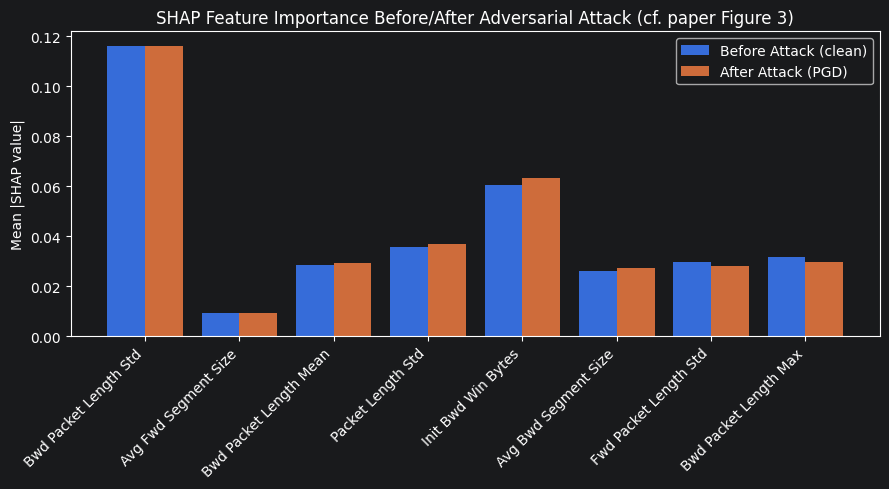

    v [03:39:32.24] Saved shap_feature_importance.png


In [16]:
log.section("Plotting SHAP feature importance (cf. paper Figure 3)")

fig, ax = plt.subplots(figsize=(9, 5))
top8 = stability_series.index[:8]
before_vals = pd.Series(shap_clean_vals, index=selected_features)[top8]
after_vals = pd.Series(shap_adv_vals, index=selected_features)[top8]

x = np.arange(len(top8))
ax.bar(x - 0.2, before_vals, width=0.4, label="Before Attack (clean)")
ax.bar(x + 0.2, after_vals, width=0.4, label="After Attack (PGD)")
ax.set_xticks(x)
ax.set_xticklabels(top8, rotation=45, ha="right")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance Before/After Adversarial Attack (cf. paper Figure 3)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_feature_importance.png"), dpi=150)
plt.show()
log.ok("Saved shap_feature_importance.png")


## Section 16 — Defended model: adversarial training + SHAP-robust features (paper Table 1)

Retrains on the SHAP-selected robust feature subset (stage 1, clean data only), then augments
training data with FGSM/PGD/DeepFool adversarial examples (generated on CPU via ART) and continues
training (stage 2, on GPU). Timing is captured separately for each phase so overhead can be reported
both ways: pure retraining cost vs. total defense-pipeline cost including adversarial example generation.

In [17]:
log.section("Training defended model - stage 1 (clean, robust features)")

feat_idx = [selected_features.index(f) for f in robust_features]
X_train_def = X_train_bal[:, feat_idx]
X_test_def = X_test[:, feat_idx]
X_atk_def = X_atk[:, feat_idx]

defended_model = IDSNet(len(robust_features))
log.info(f"Defended model input_dim={len(robust_features)} (SHAP-robust subset), device={DEVICE}")

t_stage1_start = time.time()
hist_def_stage1 = train_model(
    defended_model, X_train_def, y_train_bal,
    epochs=CONFIG["epochs_defended_stage1"], batch_size=CONFIG["batch_size"],
    device=DEVICE, desc="Defended stage 1 (clean)",
)
t_stage1_time = time.time() - t_stage1_start
log.ok(f"Stage 1 complete in {t_stage1_time/60:.2f} min")



>>> [03:39:32.35] SECTION 14: Training defended model - stage 1 (clean, robust features)
    . [03:39:32.94] Defended model input_dim=15 (SHAP-robust subset), device=privateuseone:0


Defended stage 1 (clean):   0%|          | 0/50 [00:00<?, ?it/s]

    v [07:02:33.97] Stage 1 complete in 203.02 min


In [18]:
log.section("Generating adversarial training examples (CPU via ART)")

clip_values_def = (float(X_train_def.min()), float(X_train_def.max()))
classifier_def, _ = make_art_classifier(defended_model, len(robust_features), clip_values_def)
attacks_def = make_attacks(classifier_def)

N_GEN = min(CONFIG["n_adv_train_samples"], len(X_train_def))
gen_idx = np.random.choice(len(X_train_def), N_GEN, replace=False)
X_gen, y_gen = X_train_def[gen_idx], y_train_bal[gen_idx]
log.info(f"Generating adversarial training data from {N_GEN} samples per attack type")

t_gen_start = time.time()
adv_train_X, adv_train_y = [], []
for name, atk in tqdm(list(attacks_def.items()), desc="Generating adv. training data"):
    t0 = time.time()
    # FIX: target ground truth, consistent with cells 26/37, so adversarial training
    # data is a genuine ground-truth-targeted perturbation, not model-prediction-targeted.
    X_adv_gen = atk.generate(x=X_gen, y=to_onehot(y_gen))
    if name == "DeepFool":
        # BUG FIX: same unbounded-DeepFool issue as cell 26 -- without capping,
        # this floods stage-2 training with samples pinned near clip_values
        # bounds (unrealistic feature vectors), which is what was corrupting
        # the defended model's CLEAN accuracy, not just its attacked accuracy.
        X_adv_gen = cap_to_eps(X_adv_gen, X_gen, EPS, clip_values_def)
    log.ok(f"{name}: {len(X_adv_gen)} adversarial training examples in {time.time()-t0:.1f}s")
    adv_train_X.append(X_adv_gen)
    adv_train_y.append(y_gen)
t_gen_time = time.time() - t_gen_start

X_adv_train = np.vstack(adv_train_X).astype(np.float32)
y_adv_train = np.concatenate(adv_train_y)
X_train_final = np.vstack([X_train_def, X_adv_train]).astype(np.float32)
y_train_final = np.concatenate([y_train_bal, y_adv_train])
log.ok(f"Combined clean+adversarial training set: {X_train_final.shape} | balance: {np.bincount(y_train_final)}")


>>> [07:02:34.18] SECTION 15: Generating adversarial training examples (CPU via ART)
    . [07:02:34.64] Generating adversarial training data from 5000 samples per attack type


Generating adv. training data:   0%|          | 0/3 [00:00<?, ?it/s]

    v [07:02:34.88] FGSM: 5000 adversarial training examples in 0.2s


PGD - Batches:   0%|          | 0/157 [00:00<?, ?it/s]

    v [07:02:38.40] PGD: 5000 adversarial training examples in 3.5s


DeepFool:   0%|          | 0/5000 [00:00<?, ?it/s]

    v [07:03:57.02] DeepFool: 5000 adversarial training examples in 78.6s
    v [07:03:57.27] Combined clean+adversarial training set: (7631036, 15) | balance: [3815485 3815551]


In [19]:
log.section("Training defended model - stage 2 (clean + adversarial)")

# Class-weighted loss to guard against the model collapsing to a single-class predictor
# under heavy adversarial perturbation (observed in earlier runs as F1=0 under strong attacks).
class_weights = compute_class_weight("balanced", classes=np.unique(y_train_final), y=y_train_final)
log.info(f"Class weights: {dict(enumerate(class_weights))}")

t_stage2_start = time.time()
hist_def_stage2 = train_model(
    defended_model, X_train_final, y_train_final,
    epochs=CONFIG["epochs_defended_stage2"], batch_size=CONFIG["batch_size"],
    device=DEVICE, class_weights=class_weights, desc="Defended stage 2 (clean+adv)",
)
t_stage2_time = time.time() - t_stage2_start
log.ok(f"Stage 2 complete in {t_stage2_time/60:.2f} min")

# --- Overhead bookkeeping: pure retraining vs. total pipeline (incl. adversarial generation) ---
defended_train_time_total = t_stage1_time + t_gen_time + t_stage2_time
defended_train_time_fit_only = t_stage1_time + t_stage2_time

pure_retrain_overhead_pct = (defended_train_time_fit_only - baseline_train_time) / baseline_train_time * 100
total_pipeline_overhead_pct = (defended_train_time_total - baseline_train_time) / baseline_train_time * 100

log.metric("Baseline training time", f"{baseline_train_time/60:.2f} min")
log.metric("Defended: stage1 + stage2 (fit only)", f"{defended_train_time_fit_only/60:.2f} min")
log.metric("Defended: + adversarial generation", f"{t_gen_time/60:.2f} min")
log.metric("Defended: total pipeline time", f"{defended_train_time_total/60:.2f} min")
log.metric("Overhead (retraining only)", f"{pure_retrain_overhead_pct:.1f}%")
log.metric("Overhead (full pipeline incl. attack generation)", f"{total_pipeline_overhead_pct:.1f}%")

defended_train_time = defended_train_time_total
overhead_pct = total_pipeline_overhead_pct



>>> [07:03:57.36] SECTION 16: Training defended model - stage 2 (clean + adversarial)
    . [07:03:58.07] Class weights: {0: np.float64(1.0000086489659898), 1: np.float64(0.9999913511836167)}


Defended stage 2 (clean+adv):   0%|          | 0/15 [00:00<?, ?it/s]

    v [08:03:34.63] Stage 2 complete in 59.61 min
    > [08:03:34.63] Baseline training time                     202.01 min
    > [08:03:34.63] Defended: stage1 + stage2 (fit only)       262.63 min
    > [08:03:34.63] Defended: + adversarial generation         1.37 min
    > [08:03:34.63] Defended: total pipeline time              264.00 min
    > [08:03:34.63] Overhead (retraining only)                 30.0%
    > [08:03:34.63] Overhead (full pipeline incl. attack generation) 30.7%


## Section 17 — Re-evaluate defended model against all attacks

In [20]:
log.section("Evaluating defended model")

defended_clean_metrics = evaluate(defended_model, X_test_def, y_test, DEVICE, "Defended (clean)")

classifier_def2, _ = make_art_classifier(
    defended_model, len(robust_features),
    (float(X_test_def.min()), float(X_test_def.max()))
)
attacks_def2 = make_attacks(classifier_def2)

clip_values_def2 = (float(X_test_def.min()), float(X_test_def.max()))

adv_results_after = {}
for name, atk in tqdm(list(attacks_def2.items()), desc="Attacks vs. defended model (CPU)"):
    # FIX: target ground truth (y_atk), not the defended model's own prediction.
    # This is what was causing recall to jump to ~100% under attack -- the untargeted
    # attack was "helpfully" pushing already-misclassified rows back toward correct.
    X_adv2 = atk.generate(x=X_atk_def, y=to_onehot(y_atk))
    if name == "DeepFool":
        # BUG FIX: same eps-capping as cells 26/34, applied consistently here too.
        X_adv2 = cap_to_eps(X_adv2, X_atk_def, EPS, clip_values_def2)
    adv_results_after[name] = evaluate(defended_model, X_adv2, y_atk, DEVICE, f"Defended under {name}")

# Square Attack: tabular reimplementation (ART's SquareAttack is image-only), GPU forward passes
X_sq_def = X_sq[:, feat_idx]
X_adv_square2 = tabular_square_attack(defended_model, X_sq_def, y_sq, DEVICE, desc="Square Attack (defended)")
square_after = evaluate(defended_model, X_adv_square2, y_sq, DEVICE, "Defended under Square Attack")


>>> [08:03:34.74] SECTION 17: Evaluating defended model
    > [08:03:40.10] Defended (clean)                           Acc=0.920  F1=0.834  Prec=0.760  Rec=0.925  Infer=0.0042 ms/sample


Attacks vs. defended model (CPU):   0%|          | 0/3 [00:00<?, ?it/s]

    > [08:03:40.22] Defended under FGSM                        Acc=0.882  F1=0.743  Prec=0.689  Rec=0.806  Infer=0.0015 ms/sample


PGD - Batches:   0%|          | 0/63 [00:00<?, ?it/s]

    > [08:03:41.64] Defended under PGD                         Acc=0.804  F1=0.563  Prec=0.533  Rec=0.598  Infer=0.0010 ms/sample


DeepFool:   0%|          | 0/2000 [00:00<?, ?it/s]

    > [08:04:21.96] Defended under DeepFool                    Acc=0.922  F1=0.815  Prec=0.824  Rec=0.806  Infer=0.0005 ms/sample


Square Attack (defended):   0%|          | 0/300 [00:00<?, ?it/s]

    > [08:04:31.79] Defended under Square Attack               Acc=0.844  F1=0.639  Prec=0.605  Rec=0.676  Infer=0.0010 ms/sample


## Section 18 — Summary tables and plots (cf. paper Tables 4-6, Figures 1-2)

**Table 4 now reports all four paper metrics (Accuracy, F1, Precision, Recall)** — the original v2
notebook only showed Accuracy/F1 in the table, even though `evaluate()` computed all four. That's fixed here.

In [21]:
log.section("Building summary tables")

def row(name, m):
    return (name, round(m["accuracy"] * 100, 2), round(m["f1"] * 100, 2),
            round(m["precision"] * 100, 2), round(m["recall"] * 100, 2))

rows = [row("Baseline IDS (clean)", baseline_clean_metrics)]
for name in ["FGSM", "PGD", "DeepFool"]:
    rows.append(row(f"{name} Attack (baseline)", adv_results_before[name]))
rows.append(row("Defended (clean)", defended_clean_metrics))
for name in ["FGSM", "PGD", "DeepFool"]:
    rows.append(row(f"{name} Attack (defended)", adv_results_after[name]))

table4 = pd.DataFrame(rows, columns=["Model / Condition", "Accuracy (%)", "F1-score (%)",
                                       "Precision (%)", "Recall (%)"])
print("Table 4 analogue - Accuracy, F1, Precision, Recall (all four paper metrics):")
display(table4)

table5 = pd.DataFrame([
    ("Baseline", square_before["accuracy"] * 100, square_before["f1"] * 100,
     square_before["precision"] * 100, square_before["recall"] * 100,
     (1 - square_before["accuracy"]) * 100),
    ("Defended", square_after["accuracy"] * 100, square_after["f1"] * 100,
     square_after["precision"] * 100, square_after["recall"] * 100,
     (1 - square_after["accuracy"]) * 100),
], columns=["Model", "Accuracy (%)", "F1-score (%)", "Precision (%)", "Recall (%)",
            "Attack Success Rate (%)"]).round(2)
print("\nTable 5 analogue - black-box Square Attack:")
display(table5)

table6 = pd.DataFrame([
    ("Baseline", baseline_train_time / 3600, baseline_clean_metrics["infer_ms"], "-", "-"),
    ("Defended", defended_train_time_total / 3600, defended_clean_metrics["infer_ms"],
     f"{pure_retrain_overhead_pct:.1f}%", f"{total_pipeline_overhead_pct:.1f}%"),
], columns=["Model", "Training Time (hrs)", "Inference Time (ms/sample)",
            "Overhead (retrain only)", "Overhead (full pipeline)"])
print("\nTable 6 analogue - computational overhead:")
display(table6)



>>> [08:04:31.87] SECTION 18: Building summary tables
Table 4 analogue - Accuracy, F1, Precision, Recall (all four paper metrics):


,Model / Condition,Accuracy (%),F1-score (%),Precision (%),Recall (%)
0,Baseline IDS (clean),85.84,70.54,64.51,77.82
1,FGSM Attack (baseline),57.05,40.80,28.79,69.98
2,PGD Attack (baseline),50.50,28.67,20.62,47.04
3,DeepFool Attack (baseline),83.70,64.64,59.72,70.45
4,Defended (clean),92.00,83.44,75.97,92.53
5,FGSM Attack (defended),88.20,74.29,68.89,80.61
6,PGD Attack (defended),80.40,56.35,53.26,59.81
7,DeepFool Attack (defended),92.25,81.48,82.37,80.61



Table 5 analogue - black-box Square Attack:


,Model,Accuracy (%),F1-score (%),Precision (%),Recall (%),Attack Success Rate (%)
0,Baseline,65.7,44.05,33.01,66.18,34.3
1,Defended,84.4,63.89,60.53,67.65,15.6



Table 6 analogue - computational overhead:


,Model,Training Time (hrs),Inference Time (ms/sample),Overhead (retrain only),Overhead (full pipeline)
0,Baseline,3.366866,0.000372,-,-
1,Defended,4.399993,0.004241,30.0%,30.7%



>>> [08:04:32.35] SECTION 19: Rendering comparison plots


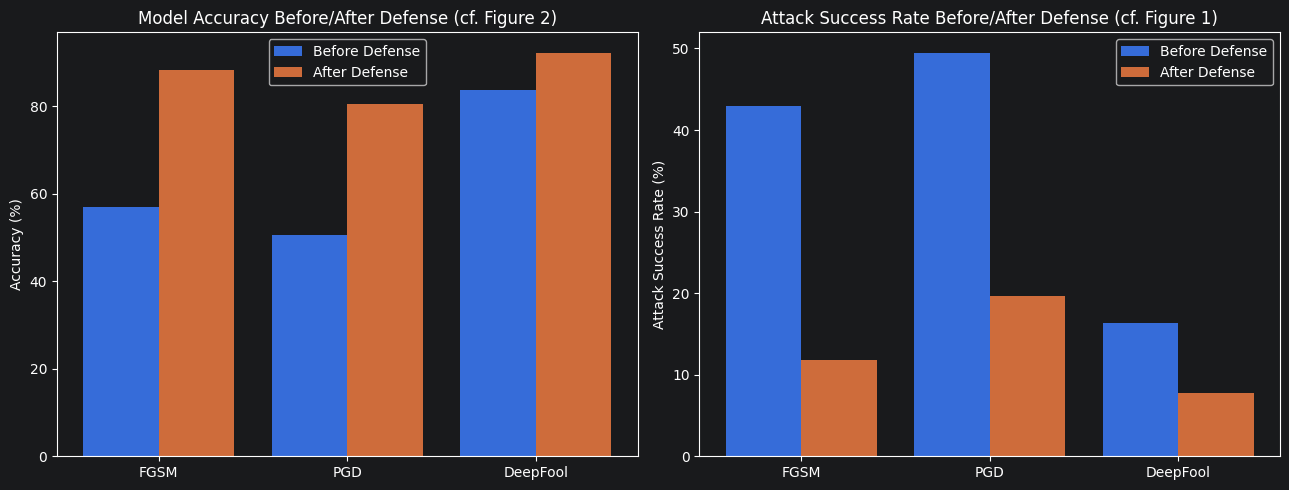

    v [08:04:32.71] Saved comparison_plots.png


In [22]:
log.section("Rendering comparison plots")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

attack_names = ["FGSM", "PGD", "DeepFool"]
before_acc = [adv_results_before[a]["accuracy"] * 100 for a in attack_names]
after_acc = [adv_results_after[a]["accuracy"] * 100 for a in attack_names]

x = np.arange(len(attack_names))
axes[0].bar(x - 0.2, before_acc, width=0.4, label="Before Defense")
axes[0].bar(x + 0.2, after_acc, width=0.4, label="After Defense")
axes[0].set_xticks(x); axes[0].set_xticklabels(attack_names)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Model Accuracy Before/After Defense (cf. Figure 2)")
axes[0].legend()

success_before = [100 - a for a in before_acc]
success_after = [100 - a for a in after_acc]
axes[1].bar(x - 0.2, success_before, width=0.4, label="Before Defense")
axes[1].bar(x + 0.2, success_after, width=0.4, label="After Defense")
axes[1].set_xticks(x); axes[1].set_xticklabels(attack_names)
axes[1].set_ylabel("Attack Success Rate (%)")
axes[1].set_title("Attack Success Rate Before/After Defense (cf. Figure 1)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_plots.png"), dpi=150)
plt.show()
log.ok("Saved comparison_plots.png")


## Section 19 — Save all artifacts to the output folder

In [23]:
log.section("Saving all results, models, and artifacts")

SAVE_DIR = OUTPUT_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

table4.to_csv(f"{SAVE_DIR}/table4_accuracy_f1_precision_recall.csv", index=False)
table5.to_csv(f"{SAVE_DIR}/table5_square_attack.csv", index=False)
table6.to_csv(f"{SAVE_DIR}/table6_overhead.csv", index=False)
log.ok("Saved tables 4-6 as CSV")

all_metrics = {
    "baseline_clean": baseline_clean_metrics,
    "baseline_under_attack": adv_results_before,
    "baseline_under_square": square_before,
    "defended_clean": defended_clean_metrics,
    "defended_under_attack": adv_results_after,
    "defended_under_square": square_after,
}
with open(f"{SAVE_DIR}/all_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2, default=float)
log.ok("Saved all_metrics.json")

torch.save(baseline_model.state_dict(), f"{SAVE_DIR}/baseline_model.pt")
torch.save(defended_model.state_dict(), f"{SAVE_DIR}/defended_model.pt")
log.ok("Saved baseline_model.pt and defended_model.pt (state_dicts; re-load with IDSNet(...).load_state_dict(...))")

with open(f"{SAVE_DIR}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
log.ok("Saved scaler.pkl")

mi_scores.to_csv(f"{SAVE_DIR}/mutual_info_scores.csv", header=["mi_score"])
stability_series.to_csv(f"{SAVE_DIR}/shap_stability_scores.csv", header=["stability_score"])
with open(f"{SAVE_DIR}/selected_features.json", "w") as f:
    json.dump({
        "mutual_info_selected": selected_features,
        "shap_robust_selected": robust_features,
        "feature_indices_used_by_defended_model": feat_idx,
    }, f, indent=2)
log.ok("Saved feature selection artifacts")

np.savez(f"{SAVE_DIR}/shap_values.npz",
         shap_clean_values=shap_clean.values, shap_adv_values=shap_adv.values,
         shap_clean_data=X_clean_shap, shap_adv_data=X_adv_shap)
log.ok("Saved shap_values.npz")

np.savez(f"{SAVE_DIR}/adversarial_examples_baseline.npz",
         X_clean=X_atk, y_clean=y_atk,
         X_fgsm=X_adv_store["FGSM"], X_pgd=X_adv_store["PGD"], X_deepfool=X_adv_store["DeepFool"],
         X_square=X_adv_square, y_square=y_sq)
log.ok("Saved adversarial_examples_baseline.npz")

np.savez(f"{SAVE_DIR}/training_history.npz",
         baseline=history, defended_stage1=hist_def_stage1, defended_stage2=hist_def_stage2)
log.ok("Saved training_history.npz")

config_snapshot = dict(CONFIG)
config_snapshot.update({
    "seed": SEED,
    "device": str(DEVICE),
    "n_attack_samples_used": N_ATTACK_SAMPLES,
    "n_square_samples_used": N_SQUARE,
    "n_shap_samples_used": N_SHAP,
    "n_adv_train_samples_used": N_GEN,
    "baseline_train_time_sec": baseline_train_time,
    "defended_stage1_time_sec": t_stage1_time,
    "defended_gen_time_sec": t_gen_time,
    "defended_stage2_time_sec": t_stage2_time,
    "defended_total_time_sec": defended_train_time_total,
    "overhead_retrain_only_pct": pure_retrain_overhead_pct,
    "overhead_full_pipeline_pct": total_pipeline_overhead_pct,
})
with open(f"{SAVE_DIR}/run_config.json", "w") as f:
    json.dump(config_snapshot, f, indent=2, default=str)
log.ok("Saved run_config.json")

for fname in ["shap_feature_importance.png", "comparison_plots.png"]:
    src = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(os.path.join(SAVE_DIR, fname)) and os.path.exists(src):
        pass  # already saved directly into SAVE_DIR (== OUTPUT_DIR)

shutil.make_archive(os.path.join(os.path.dirname(SAVE_DIR.rstrip("/")) or ".", "all_results"), "zip", SAVE_DIR)
log.ok(f"Zipped everything to {os.path.join(os.path.dirname(SAVE_DIR.rstrip('/')) or '.', 'all_results.zip')}")

log.section("RUN COMPLETE")
log.metric("Total wall-clock time", log._elapsed())
log.info(f"Files in {SAVE_DIR}/:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"        - {f}")



>>> [08:04:32.76] SECTION 20: Saving all results, models, and artifacts
    v [08:04:32.81] Saved tables 4-6 as CSV
    v [08:04:32.81] Saved all_metrics.json
    v [08:04:32.86] Saved baseline_model.pt and defended_model.pt (state_dicts; re-load with IDSNet(...).load_state_dict(...))
    v [08:04:32.86] Saved scaler.pkl
    v [08:04:32.90] Saved feature selection artifacts
    v [08:04:32.91] Saved shap_values.npz
    v [08:04:32.91] Saved adversarial_examples_baseline.npz
    v [08:04:32.91] Saved training_history.npz
    v [08:04:32.91] Saved run_config.json
    v [08:04:33.13] Zipped everything to .\all_results.zip

>>> [08:04:33.13] SECTION 21: RUN COMPLETE
    > [08:04:33.13] Total wall-clock time                      08:04:33.13
    . [08:04:33.13] Files in ./output/:
        - adversarial_examples_baseline.npz
        - all_metrics.json
        - baseline_model.pt
        - comparison_plots.png
        - defended_model.pt
        - mutual_info_scores.csv
        - run_config.j

## Notes on fidelity to the paper

- **What matches:** the full pipeline (clean -> attack -> measure degradation -> dual-layer defense
  -> re-measure), all four attack types, the SHAP-based feature-stability selection algorithm
  (Table 3), and both an overhead-only and full-pipeline overhead number (Table 6). Table 4 now
  reports all four of the paper's metrics (Accuracy, F1, Precision, Recall), not just two.
- **What can't match exactly:** the paper's specific accuracy figures — it never publishes layer
  sizes, attack epsilons/iterations, feature-selection thresholds, SMOTE settings, or which daily
  CSVs were used, so an exact numeric reproduction isn't achievable, only a faithful reimplementation
  of the same method.
- **PyTorch vs. TensorFlow:** this is a from-scratch PyTorch port (same architecture: 128-64-32 MLP,
  BatchNorm, Dropout(0.3), Adam lr=0.001) of the original TensorFlow/Keras reimplementation, so absolute
  numbers will differ slightly (different init, optimizer internals, BN implementation) even with the
  same seed — expect the same *qualitative* pattern (large accuracy drop under attack, recovered by defense).
- **GPU note:** your RX7600's DirectML backend is used for training/inference; ART attacks are
  pinned to CPU because DirectML's autograd/numpy interop isn't reliable enough for ART's
  gradient-based attacks.
- **Main tuning levers**, all in `CONFIG` at the top: `attack_eps` (smaller -> closer to the paper's
  more modest pre-defense degradation), `day_patterns` (more files -> more data, slower),
  `top_t_mutual_info`/`top_t_shap` (feature counts), and the epoch counts for each training stage.
